<img src="https://github.com/GJay99/Trabajos_APS/blob/master/TS0/logo_UNSAM.jpg?raw=1" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº2
#### Gonzalo Jay

# Introducción
En esta tarea semanal 2 tuvimos el objetivo de realizar la modelización de un conversor analógico-digital, analizando no solo la señal de salida, sino también como se comporta el ruido de cuantización.

Para esto volvimos a utilizar la FFT en conjunto de una nueva herramienta de análisis, la correlación. Además, utilizamos un test de hipótesis estudiado en probabilidad y estadística para evaluar la teoría de que el ruido de cuantización se comporta como una distribución uniforme.

El análisis lo haremos sobre una señal senoidal, con una $f_0 = \frac{f_s}{N} = \Delta f$ y Potencia = 1W. Además, debemos agregarle una secuencia de ruido la cual será incorrelada y Gaussiana. Esta señal deberá cumplir que $P_n = k_n . P_q$ siendo k una escala para la potencia del ruido de cuantización.

# Resolución
Cómo al comienzo de cada tarea semanal, importaremos las librerías que debemos utilizar y algunas constantes útiles.

In [1]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from scipy.stats import kstest

In [2]:
fs=1000
N=1000

Además, agregamos funciones que fuimos creando durante los trabajos anteriores para reutilizar a lo largo del código.

In [3]:
def mi_funcion_seno(vmax = 1, dc = 0, ff = 1, ph = 0, nn = N, fs = fs):
    tt=np.zeros(nn)
    xx=np.zeros(nn)
    for n in np.arange(0,nn,1):
        tt[n]= n * (1/fs)
        xx[n]= vmax * np.sin(2*np.pi*ff * tt[n] + ph) + dc
    return tt, xx

def mi_fft(x,ref=0):
    x_fft = fft(x)
    x_fft = x_fft[:N//2]

    freq = fftfreq(N,1/fs)
    freq = freq[:N//2]

    x_fft_abs = np.abs(x_fft)
    
    return freq, x_fft_abs

## Análisis de ADC con 4 bits y $k_n$ = 1
El primer caso que debemos estudiar es cuando nuestro ADC tiene únicamente 4 bits y un $k_n$ de 1. En principio, lo que debemos obtener como salida es una señal con $2^4$ niveles de tensión, frecuencia 1 Hz y una potencia de ruido igual a la potencia del ruido de cuantización.

Para ver esto tenemos que:
\begin{equation}
f_0 = \frac{f_s}{N} = \frac{1000 Hz}{1000} = 1 Hz
\end{equation}
\begin{equation}
q = \frac{V_{ref+}-V_{ref-}}{2^4} = \frac{2*V_{ref}}{2^4}
\end{equation}
\begin{equation}
P_n = k_n . P_q => P_n = P_q = \frac{q^2}{12} \approx  5.2 mW
\end{equation}
Además como se nos pide que la potencia del seno sea unitaria, debemos volver a utilizar una amplitud de $\sqrt{2}$.

Entonces, ahora simplemente creamos la señal senoidal y agregamos todos los parámetros que acabamos de mencionar.

In [4]:
t,s = mi_funcion_seno(vmax = np.sqrt(2),ff=fs/N)

In [5]:
n_bits = 4
k_n = 1
Vfs = 2
q = (2*Vfs)/(np.pow(2,n_bits))
P_q = q**2/12
P_n = k_n * P_q

Ahora, utilizando la potencia que deseamos que tenga el ruido, generamos la normal considerando que:
\begin{equation}
\sigma^2 \approx P_n => sigma = \sqrt{P_n}
\end{equation}

In [6]:
sigma = np.sqrt(P_n)
n = np.random.normal(scale=sigma,size=len(t))

Continuamos generando la señal ruidosa agregando aditivamente el ruido y nuestra senoidal ideal, para luego agregarle los límites de amplitud de $V_fs$ para que en caso de que la amplitud de la señal lo supere a causa del ruido, lo cuál sería probabilísticamente muy difícil, el ADC sature. Una vez realizado esto, ahora sí, lo pasamos por nuestra modelización de un ADC.

In [7]:
sn = s+n
sn_limitada = np.clip(sn, -Vfs, Vfs)
sn_cuantizada = np.round(sn_limitada/q)*q

Para visualizar todo este proceso, graficamos en un mismo plot el seno ideal, la señal ruidosa y la señal ruidosa cuantizada.

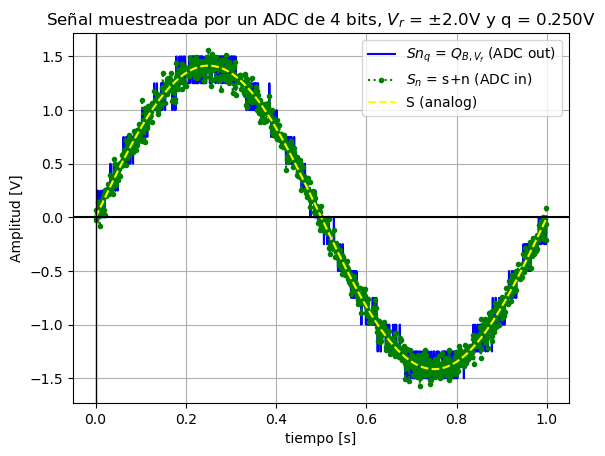

In [8]:
plt.figure(1)
plt.plot(t,sn_cuantizada,color = "blue",label="$Sn_q$ = $Q_{B,V_f}$ (ADC out)")
plt.plot(t,sn,":.",color = "green",label="$S_n$ = s+n (ADC in)")
plt.plot(t,s,linestyle="--",marker=" ",color = "yellow",label="S (analog)")
plt.title(f"Señal muestreada por un ADC de {n_bits} bits, $V_r$ = ±{Vfs:.1f}V y q = {q:.3f}V")
plt.xlabel("tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)
plt.legend()

Podemos apreciar como el ruido analógico distorsiona la señal original visiblemente, además de que la cuantización también modifica levemente la forma de la misma.

Ahora, lo que nos va a interesar es ver como esto afecta en el dominio de la frecuencia, y para eso debemos analizar su FFT. No solo haremos la FFT de la señal cuantizada, si no que también del ruido analógico y del ruido de cuantización.

Repasando lo que esperamos ver, si nuestra señal fuera un seno ideal deberíamos ver un $\delta$ de 0dB en 1 Hz y números muy negativos en el resto de frecuencia, correspondientes a tomar logaritmos en valores que deberían ser 0 pero por errores numéricos son cercanos. En este caso, al agregarle una señal ruidosa y el ruido de cuantización lo que esperamos es ver como además se le agrega un piso de ruido de orden similar a la suma de las potencias espectrales propias de cada uno de los ruidos de manera individual.

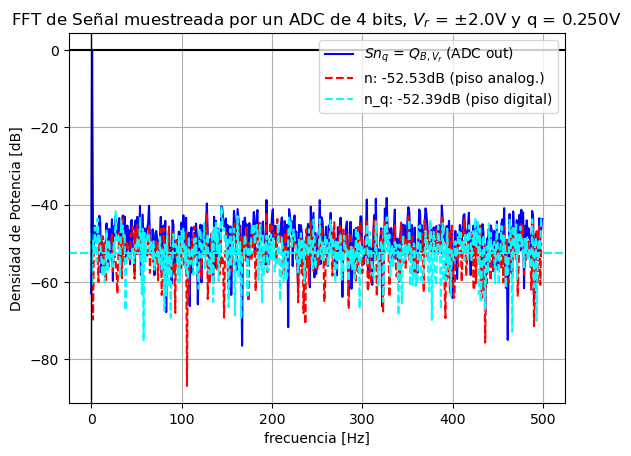

In [9]:
freq, sn_fft_abs = mi_fft(sn)
ref = np.max(sn_fft_abs)

freq, sn_cuantizada_fft_abs = mi_fft(sn_cuantizada)
sn_cuantizada_fft_dB = 20 * np.log10(sn_cuantizada_fft_abs/ref)

freq, n_fft_abs = mi_fft(n)
n_fft_dB = 20 * np.log10(n_fft_abs/ref)

n_q = sn_cuantizada - sn
freq, n_q_fft_abs = mi_fft(n_q)
n_q_fft_dB = 20 * np.log10(n_q_fft_abs/ref)

plt.figure(2)
plt.plot(freq,sn_cuantizada_fft_dB,color="blue",label="$Sn_q$ = $Q_{B,V_f}$ (ADC out)")
plt.plot(freq,n_fft_dB,linestyle ="--", color="red")
plt.axhline(np.mean(n_fft_dB), color="red", linestyle="--", label=f"n: {np.mean(n_fft_dB):.2f}dB (piso analog.)")
plt.plot(freq,n_q_fft_dB,linestyle ="--",color="cyan")
plt.axhline(np.mean(n_q_fft_dB), color="cyan", linestyle='--', label=f"n_q: {np.mean(n_q_fft_dB):.2f}dB (piso digital)")

plt.legend()
plt.title(f"FFT de Señal muestreada por un ADC de {n_bits} bits, $V_r$ = ±{Vfs:.1f}V y q = {q:.3f}V")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)


Podemos ver como nuestras predicciones se cumplen. En principio, tenemos nuestro delta de 0 dB y 1 Hz con un piso de ruido mas elevado a lo que solíamos ver cuando graficabamos la FFT de un seno ideal. Además, podemos ver como el piso de ruido analógico y el digital se encuentran muy cerca el uno del otro, teniendo un valor medio similar. Esto concuerda con que hayamos utilizado un $k_n$ = 1.

A partir de ahora lo que haremos es analizar el comportamiento del ruido de cuantización. Para esto partimos del conocimiento teórico que tenemos de que el ruido de cuantización debe distribuirse de manera uniforme entre $\{-\frac{q}{2};\frac{q}{2}\}$. Trataremos de demostrar esto mediante un histograma, para tener un apoyo visual, y un test de hipótesis, para verificar que tan probable es que nuestra distribución sea, efectivamente, una uniforme.

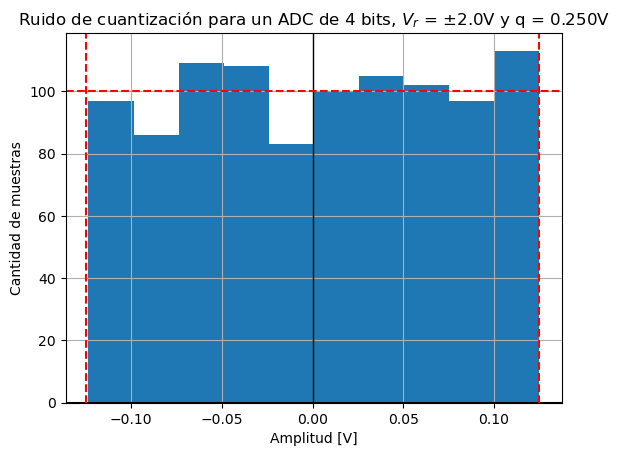

In [10]:
plt.figure(3)
plt.hist(n_q)
plt.title(f"Ruido de cuantización para un ADC de {n_bits} bits, $V_r$ = ±{Vfs:.1f}V y q = {q:.3f}V")
plt.ylabel("Cantidad de muestras")
plt.xlabel("Amplitud [V]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)
plt.axvline(-q/2, linestyle="--",color="red")
plt.axvline(q/2, linestyle="--",color="red")
plt.axhline(100, linestyle="--",color="red")


Como primer instancia, el histograma nos muestra algo que cumple con lo que esperábamos ver. Una amplitud que va entre  $\{-\frac{q}{2};\frac{q}{2}\}$ y aproximadamente la misma cantidad de puntos en cada bin. Pero si bien esto nos ayuda a convencernos de que probablemente se trate de una uniforme, no es suficiente. Para tener una comprobación mas robusta decidimos utilizar un test de hipótesis conocido como Kolmogórov-Smirnov, el cuál se encuentra integrado en la librería $scipy.stats$. Para esto planteamos la siguiente hipótesis:
\begin{equation}
H_0:\ \text{El ruido de cuantización sigue una distribución uniforme entre}\ \{-\frac{q}{2};\frac{q}{2}\}
\end{equation}
\begin{equation}
H_1\ \text{El ruido de cuantización NO sigue una distribución uniforme entre}\ \{-\frac{q}{2};\frac{q}{2}\}
\end{equation}
Intervalo de confianza: 
\begin{equation}
\text{Intervalo de confianza: }95\%
\end{equation}
Donde usamos $\alpha=0.05$ como nivel de significancia, que implica trabajar con un nivel de confianza del 95%, por ser el valor usual que se considera aceptable en este tipo de test.

In [11]:
a = -q/2
b = q/2

resultado = kstest(n_q, 'uniform', args=(a, b-a))

alpha = 0.05
if resultado.pvalue < alpha:
    print("La señal no es compatible con una distribución uniforme.")
else:
    print("No hay evidencia suficiente para afirmar que la señal no sea uniforme.")


No hay evidencia suficiente para afirmar que la señal no sea uniforme.


Como el valor $p$ obtenido es mayor al $\alpha$ propuesto, no existe evidencia estadística para rechazar la $H_0$, por lo que los resultados obtenidos son compatibles con la hipótesis de ser una distribución uniforme. Pero aún nos falta un detalle, comprobar si este ruido es incorrelado. Para eso, analizamos su autocorrelación.

0.005174510674908849


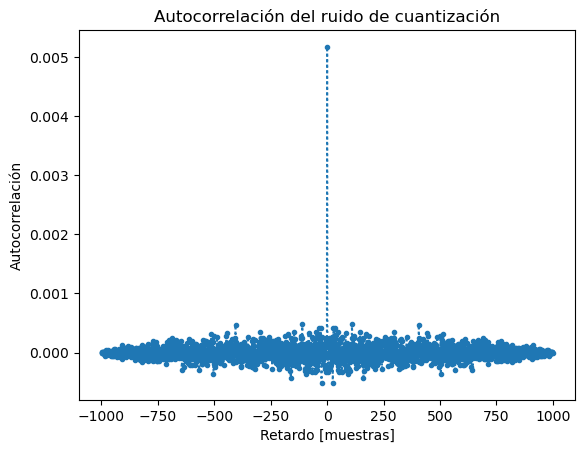

In [12]:
correlacion = np.correlate(n_q,n_q,"full")/N
lags = np.arange(-(N-1), N)

plt.figure(4)
plt.plot(lags, correlacion,":.")
plt.title("Autocorrelación del ruido de cuantización")
plt.xlabel("Retardo [muestras]")
plt.ylabel("Autocorrelación")

print(np.mean(n_q**2))

Este gráfico nos permite ver cómo el único caso donde la correlación toma un valor significativamente distinto de 0 es cuando el retardo es 0, es decir, cuando se esta tomando la correlación de un punto consigo mismo. Este valor, por definición, debe ser igual a la potencia de la señal, lo cuál se cumple como podemos ver en el print del código (no tiene sentido escribir el valor porque al tratarse de la cuantización de una señal con ruido aleatorio el mismo variará levemente si volvemos a correr el código).

## Análisis de ADC con 4 bits y $k_n$ = 1/10
Ahora analizaremos que pasa si con la misma cantidad de bits, cambiamos el $k_n$ a $\frac{1}{10}$. Esta situación sería, a cantidad fija de bits, la de menor ruido entre las opciones que teníamos de $k_n = \{\frac{1}{10},1,10\}$ ya que $P_q$ será un valor aproximadamente fijo y:
\begin{equation}
P_n = k_n . P_q = \frac{P_q}{10}
\end{equation}
A partir de este paso repetimos lo que hicimos en el análisis anterior. Declaramos algunas variables útiles, generamos nuestro ruido, lo agregamos al seno y ploteamos.

In [13]:
k_n = 1/10
q = (2*Vfs)/(np.pow(2,n_bits))
P_q = q**2/12
P_n = k_n * P_q
sigma = np.sqrt(P_n)
n = np.random.normal(scale=sigma,size=len(t))

In [14]:
sn = s+n

sn_limitada = np.clip(sn, -Vfs, Vfs)
sn_cuantizada = np.round(sn_limitada/q)*q

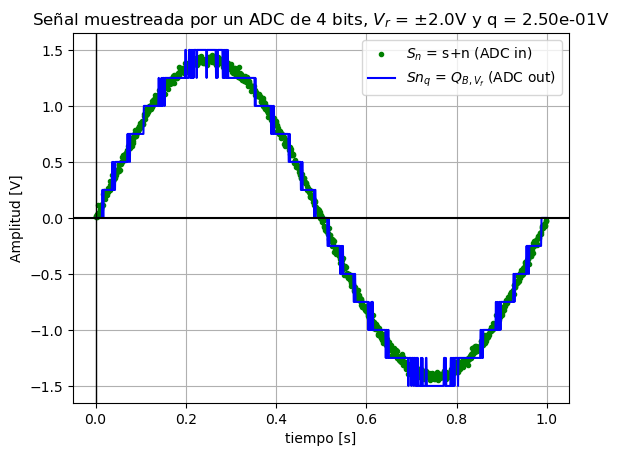

In [15]:
plt.figure(5)
plt.plot(t,sn," .",color = "green",label="$S_n$ = s+n (ADC in)")
plt.plot(t,sn_cuantizada,color = "blue",label="$Sn_q$ = $Q_{B,V_f}$ (ADC out)")
plt.title(f"Señal muestreada por un ADC de {n_bits} bits, $V_r$ = ±{Vfs:.1f}V y q = {q:.2e}V")
plt.xlabel("tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)
plt.legend()

Podemos ver como se cumplió lo que esperábamos, pues la señal cuantizada se asemeja más a la de un seno ideal (considerando los escalones propios de tener una resolución de 4 bits) que en el caso anterior, con algunos saltos extra debido a la presencia del ruido. Sin embargo, en el primer caso por ejemplo veíamos como había algunos puntos que se escapaban del rango de la amplitud de la senoide, mientras que en este caso el máximo corresponde al valor donde caería el máximo de la misma senoide en un caso sin ruido.

Ahora procederemos a ver que cambios se apreciarán en la FFT. Lo que podemos esperar es que el piso del ruido analógico se encuentre por debajo del digital, ya que al ser de 1 orden de magnitud menor esperamos encontrarnos con un valor 10 dB por debajo del piso del ruido de cuantización. Esto hará que además el piso de ruido de la señal cuantizada sea prácticamente igual al piso de ruido de la cuantización, lo cuál es lógico debido a que la potencia del ruido será en su mayor parte debida a este error.

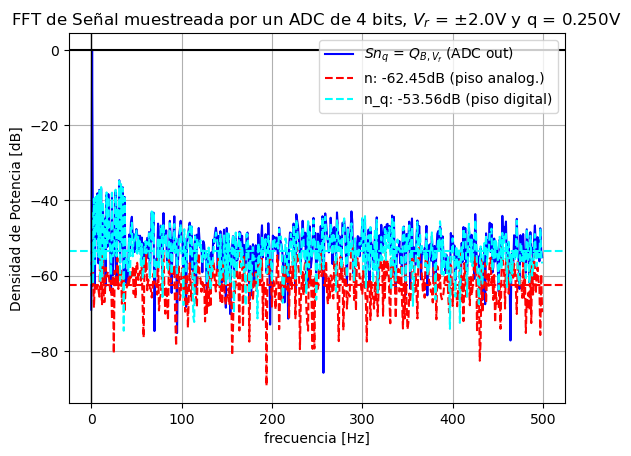

In [16]:
freq, sn_fft_abs = mi_fft(sn)
ref = np.max(sn_fft_abs)

freq, sn_cuantizada_fft_abs = mi_fft(sn_cuantizada)
sn_cuantizada_fft_dB = 20 * np.log10(sn_cuantizada_fft_abs/ref)

freq, n_fft_abs = mi_fft(n)
n_fft_dB = 20 * np.log10(n_fft_abs/ref)

n_q = sn_cuantizada - sn
freq, n_q_fft_abs = mi_fft(n_q)
n_q_fft_dB = 20 * np.log10(n_q_fft_abs/ref)

plt.figure(6)
plt.plot(freq,sn_cuantizada_fft_dB,color="blue",label="$Sn_q$ = $Q_{B,V_f}$ (ADC out)")
plt.plot(freq,n_fft_dB,linestyle ="--", color="red")
plt.axhline(np.mean(n_fft_dB), color="red", linestyle="--", label=f"n: {np.mean(n_fft_dB):.2f}dB (piso analog.)")
plt.plot(freq,n_q_fft_dB,linestyle ="--",color="cyan")
plt.axhline(np.mean(n_q_fft_dB), color="cyan", linestyle='--', label=f"n_q: {np.mean(n_q_fft_dB):.2f}dB (piso digital)")

plt.legend()
plt.title(f"FFT de Señal muestreada por un ADC de {n_bits} bits, $V_r$ = ±{Vfs:.1f}V y q = {q:.3f}V")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Nuevamente, las predicciones que hemos realizado se cumplen. Lo mas importante es apreciar como $n \approx n_q - 10dB$ que debería ser el principal cambio de este gráfico en relación al anterior.

Cómo último análisis de este trabajo nos disponemos a analizar lo que sucede con el ruido de cuantización de esta señal. Para eso, nuevamente, recurriremos al histograma y al test de hipótesis.

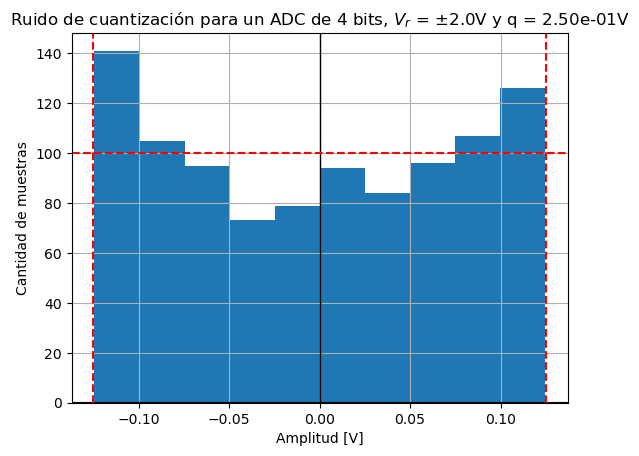

In [17]:
plt.figure(7)
plt.hist(n_q)
plt.title(f"Ruido de cuantización para un ADC de {n_bits} bits, $V_r$ = ±{Vfs:.1f}V y q = {q:.2e}V")
plt.ylabel("Cantidad de muestras")
plt.xlabel("Amplitud [V]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)
plt.axvline(-q/2, linestyle="--",color="red")
plt.axvline(q/2, linestyle="--",color="red")
plt.axhline(100, linestyle="--",color="red")



Ya en este histograma nos encontramos algo "inesperado". La distribución dejó de asemejarse a una uniforme, sino que más bien se asemeja a una U, donde existen menor cantidad de datos con error semejante a 0 y más con un valor absoluto de $\frac{q}{2}$. Antes de hacer ninguna conclusión, comprobamos nuevamente con el test de Kolmogórov-Smirnov.

In [18]:
a = -q/2
b = q/2

resultado = kstest(n_q, 'uniform', args=(a, b-a))

alpha = 0.05
if resultado.pvalue < alpha:
    print("La señal no es compatible con una distribución uniforme.")
else:
    print("No hay evidencia suficiente para afirmar que la señal no sea uniforme.")


La señal no es compatible con una distribución uniforme.


En contra de los esperado, nuevamente, el test nos dice que la señal de ruido no es compatible con una uniforme y la hipótesis nula fue rechazada. Esto se puede explicar debido a que al tener un ruido gaussiano de orden menor frente al paso de cuantización, el ruido digital conservará una mayor dependencia con la señal de entrada y el error tendrá un comportamiento menos aleatorio, dependerá directamente de los valores de la senoide ideal.

Si este análisis es correcto también habrá otra consecuencia, el ruido no será completamente incorrelado. Pero, como ya he dicho previamente, antes de concluir nada veamos que sucede.

0.006013250233441618


Text(0, 0.5, 'Autocorrelación')

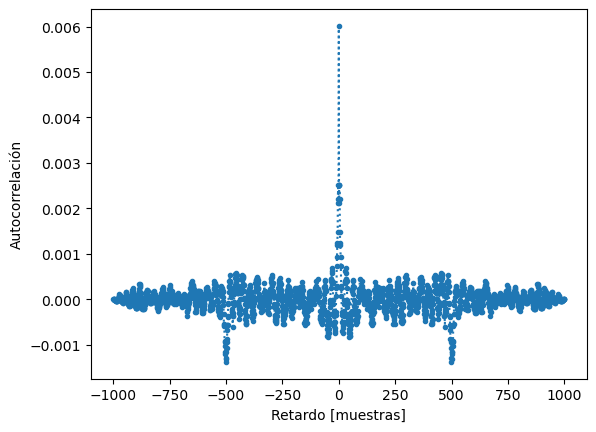

In [19]:
correlacion = np.correlate(n_q,n_q,"full")/N
lags = np.arange(-(N-1), N)
print(np.mean(n_q**2))
    
plt.figure(8)
plt.plot(lags, correlacion,":.")
plt.xlabel("Retardo [muestras]")
plt.ylabel("Autocorrelación")


Efectivamente, el ruido no se encuentra incorrelado con si mismo. En el 0 de lag tenemos la potencia de la señal de ruido, igual que en el caso anterior, pero ahora aparecer valores de autocorrelación apreciables para valores distintos de cero. Esto nos da a entender que, como consecuencia de disminuir el ruido aleatorio y tener una señal de entrada prácticamente determinística, el error de cuantización presenta una mayor dependencia de la senoidal, lo que genera una dependencia temporal que impide que el modelo de ruido blanco e incorrelado siga siendo una buena aproximación.

# Conclusión
A lo largo de este trabajo surgieron varias conclusiones que considero que son importantes de mencionar.

En primera instancia, pudimos observar como tanto el ruido de cuantización como el ruido analógico aumentan el piso de ruido de la FFT del seno. Es decir que la FFT de una señal a la que se le agrega ruido incorrelado de manera aditiva seguirá teniendo el comportamiento de la transformada de la función original, solo que se le agregará un piso de ruido de un orden similar al de ambos ruidos.

Por otro lado, analizando el ruido de cuantización tuvimos resultados diversos en los distintos casos. Por un lado, si la señal de entrada presenta una componente de ruido aleatorio de una potencia suficientemente significativa, el ruido de cuantización en consecuencia heredará este comportamiento aleatorio y adoptará una distribución uniforme e incorrelada. En cambio, mientras mas determinística sea la señal de entrada, es decir menor sea la potencia del ruido aleatorio, mas correlación temporal tendrá el ruido y ya no será compatible con una uniforme.

Todo este análisis se realizó con un modelo de ADC con una cantidad de bits fija. Un caso de estudio interesante para analizar a futuro sería también cómo cambia el ruido de cuantización y la FFT del seno en función de la resolución del conversor.